# Quantum CTEM Advanced Tutorial

This notebook demonstrates advanced quantum Conventional Transmission Electron Microscopy (CTEM) simulations using QuScope.

## Topics Covered

1. Quantum wavefunction encoding
2. Momentum space operations with QFT
3. Weak Phase Object Approximation (WPOA)
4. Contrast Transfer Function (CTF) modeling
5. Full quantum CTEM simulation workflow

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit.library import QFT, QFTGate
from qiskit.quantum_info import Statevector
from ase.build import graphene
import abtem

# QuScope imports
import quscope
from quscope.quantum_ctem.backends import get_backend
from quscope.quantum_ctem.materials import get_material
from quscope.quantum_ctem.quantum_wave_function import QuantumWaveFunction
from quscope.ctem import KirklandPotential
from quscope.quantum_ctem import (
    QuantumCTEMParameters, QuantumCTEMCircuit, QuantumClassicalValidator,
)
from quscope.quantum_ctem.quantum_ctem_circuit import (
    relativistic_wavelength, interaction_constant,
    PhaseGratingCircuit, LensCTFCircuit,
)

print(f"QuScope v{quscope.__version__}")

# Set up backend
backend = get_backend('simulator')
backend.connect()
print(f"Backend initialized: {backend.__class__.__name__}")


QuScope v0.2.0
Backend initialized: SimulatorBackend


## 1. Understanding Quantum Wavefunction Encoding

In quantum CTEM, we encode the electron wavefunction into quantum states. Each pixel's amplitude and phase information is represented in the quantum circuit.

Wavefunction shape: (8, 8)
Required qubits: 6


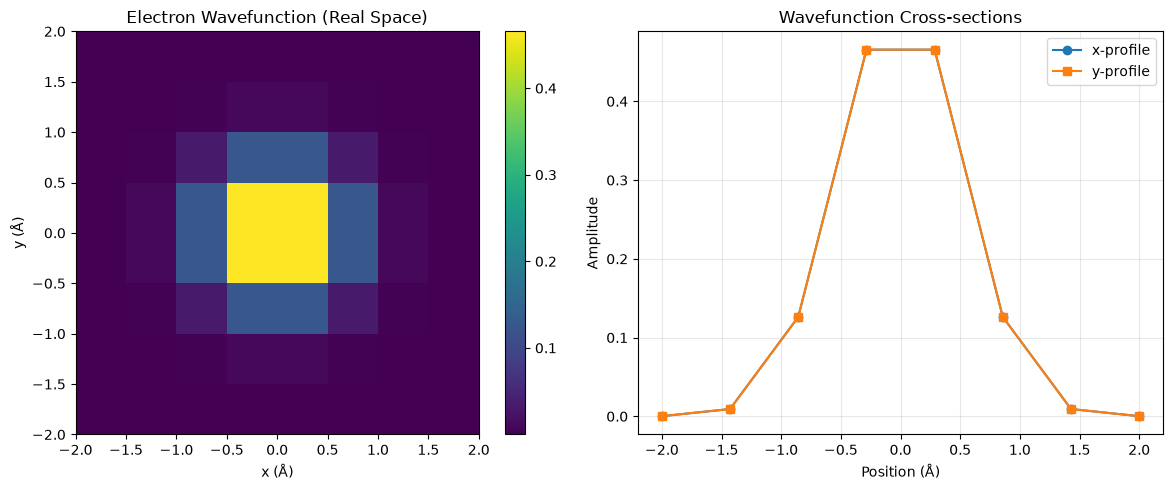

In [2]:
# Create a simple wavefunction (8x8 grid)
grid_size = 8
n_qubits = int(np.log2(grid_size * grid_size))

# Create a Gaussian wavefunction
x = np.linspace(-2, 2, grid_size)
y = np.linspace(-2, 2, grid_size)
X, Y = np.meshgrid(x, y)

# Gaussian centered at origin
sigma = 0.5
wavefunction = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
wavefunction = wavefunction / np.linalg.norm(wavefunction)

print(f"Wavefunction shape: {wavefunction.shape}")
print(f"Required qubits: {n_qubits}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im1 = axes[0].imshow(wavefunction, cmap='viridis', extent=[-2, 2, -2, 2])
axes[0].set_title('Electron Wavefunction (Real Space)')
axes[0].set_xlabel('x (Å)')
axes[0].set_ylabel('y (Å)')
plt.colorbar(im1, ax=axes[0])

# Profile through center
axes[1].plot(x, wavefunction[grid_size//2, :], 'o-', label='x-profile')
axes[1].plot(y, wavefunction[:, grid_size//2], 's-', label='y-profile')
axes[1].set_title('Wavefunction Cross-sections')
axes[1].set_xlabel('Position (Å)')
axes[1].set_ylabel('Amplitude')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Quantum Circuit Encoding

Encode the wavefunction into a quantum circuit using amplitude encoding.

In [3]:
# Initialize quantum wavefunction encoder
# QuantumWaveFunction takes separate x and y qubit counts
n_qubits_x = n_qubits // 2
n_qubits_y = n_qubits // 2

qwf = QuantumWaveFunction(n_qubits_x=n_qubits_x, n_qubits_y=n_qubits_y)

# Encode the wavefunction into quantum circuit
circuit = qwf.prepare_arbitrary_wave(wavefunction)

print(f"Encoded circuit:")
print(f"  Qubits: {circuit.num_qubits}")
print(f"  Depth: {circuit.depth()}")
print(f"  Gates: {circuit.size()}")

# Visualize circuit (truncated for readability)
if circuit.depth() < 50:
    # Use text output format (doesn't require pylatexenc)
    print("\nCircuit structure (text format):")
    print(circuit)
else:
    print("\nCircuit too complex to display (depth > 50)")
    print("The circuit uses amplitude encoding to prepare the quantum state.")

Encoded circuit:
  Qubits: 6
  Depth: 1
  Gates: 1

Circuit structure (text format):
     »
q_0: »
     »
q_1: »
     »
q_2: »
     »
q_3: »
     »
q_4: »
     »
q_5: »
     »
«     ┌──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
«q_0: ┤0                                                                                                                                                             

## 3. Momentum Space with Quantum Fourier Transform

The QFT transforms our wavefunction to momentum space, essential for simulating propagation.

C:\Users\seanl\AppData\Local\Temp\ipykernel_31360\2522749023.py:3: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft_circuit.append(QFT(n_qubits, do_swaps=True), range(n_qubits))


QFT circuit:
  Total depth: 2
  Total gates: 2


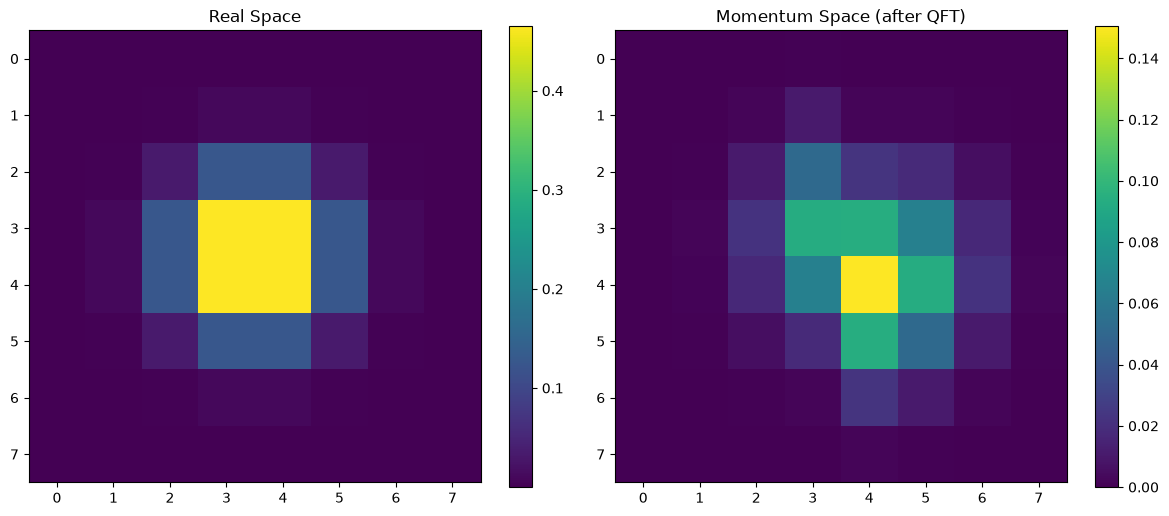

In [4]:
# Apply QFT to transform to momentum space
qft_circuit = circuit.copy()
qft_circuit.append(QFT(n_qubits, do_swaps=True), range(n_qubits))

print(f"QFT circuit:")
print(f"  Total depth: {qft_circuit.depth()}")
print(f"  Total gates: {qft_circuit.size()}")

# Simulate to get momentum space representation
from qiskit.quantum_info import Statevector

# Get statevector
sv = Statevector.from_instruction(qft_circuit)
momentum_amplitudes = np.abs(sv.data)**2
momentum_space = momentum_amplitudes.reshape(grid_size, grid_size)

# Compare real and momentum space
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im1 = axes[0].imshow(wavefunction, cmap='viridis')
axes[0].set_title('Real Space')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(np.fft.fftshift(momentum_space), cmap='viridis')
axes[1].set_title('Momentum Space (after QFT)')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

## 4. Weak Phase Object Approximation (WPOA)

WPOA is valid for thin specimens where the phase shift is small.

In [5]:
# Create a realistic graphene monolayer using abTEM/ASE for the atomic
# structure, then compute its projected potential with QuScope's own
# Kirkland scattering-factor parametrization (quscope.ctem.KirklandPotential) --
# the same physics used by the rest of the package -- rather than an
# arbitrary Gaussian.
grid_size_large = 64
voltage = 200e3  # 200 keV electron beam; used for the whole graphene demo below

# Create orthogonal graphene cell (abTEM style), tiled close to a SQUARE field
# of view (7 x 4 cells: 17.22 x 17.04 A) so the projected potential can use a
# single, physically consistent (isotropic) pixel size -- required both by the
# CTF/QFT frequency grid below and by QuantumCTEMCircuit, which takes one
# scalar `pixel_size` for a square N x N grid.
atoms = abtem.orthogonalize_cell(graphene(vacuum=2))
atoms *= (7, 4, 1)

positions = atoms.get_positions()[:, :2]  # x, y only
L = min(atoms.cell[0, 0], atoms.cell[1, 1])   # square field of view (A)
pixel_size = L / grid_size_large              # real, isotropic pixel size (A)

print(f"Graphene monolayer from abTEM:")
print(f"  Atoms in tiled cell: {len(atoms)}")
print(f"  Cell dimensions: {atoms.cell[0, 0]:.2f} x {atoms.cell[1, 1]:.2f} A")
print(f"  Square field of view: {L:.2f} x {L:.2f} A "
      f"({grid_size_large}x{grid_size_large} grid, {pixel_size:.4f} A/pixel)")
print(f"  Lattice constant: ~2.46 A (C-C bond ~1.42 A)")

# Real-space grid at the pixel CENTRES (Angstroms)
coords = (np.arange(grid_size_large) + 0.5) * pixel_size
X_large, Y_large = np.meshgrid(coords, coords, indexing="ij")

# Kirkland-parametrized projected potential (V*A) for carbon, Z=6. Atoms just
# outside the square crop are still included (small margin) so their
# potential tails aren't abruptly clipped at the field-of-view boundary.
kirkland = KirklandPotential()
margin = 3.0  # A; the Kirkland potential falls off quickly beyond a few A
in_view = [(x, y) for x, y in positions
           if -margin <= x < L + margin and -margin <= y < L + margin]

V_proj = np.zeros((grid_size_large, grid_size_large))
for x_pos, y_pos in in_view:
    V_proj += kirkland.calculate_2d(X_large, Y_large, atom_x=x_pos, atom_y=y_pos, Z=6)

print(f"\n✓ Graphene projected potential computed (Kirkland parametrization):")
print(f"  Grid: {grid_size_large}x{grid_size_large} pixels")
print(f"  Atoms contributing (incl. {margin:.0f} A margin): {len(in_view)}")
print(f"  Potential range: [{V_proj.min():.2f}, {V_proj.max():.2f}] V·A")


Graphene monolayer from abTEM:
  Atoms in tiled cell: 112
  Cell dimensions: 17.22 x 17.04 A
  Square field of view: 17.04 x 17.04 A (64x64 grid, 0.2663 A/pixel)
  Lattice constant: ~2.46 A (C-C bond ~1.42 A)

✓ Graphene projected potential computed (Kirkland parametrization):
  Grid: 64x64 pixels
  Atoms contributing (incl. 3 A margin): 112
  Potential range: [0.24, 750.29] V·A


Relativistic wavelength at 200 keV: 0.02508 Å
Interaction constant sigma: 7.2884e-04 rad/(V·Å)


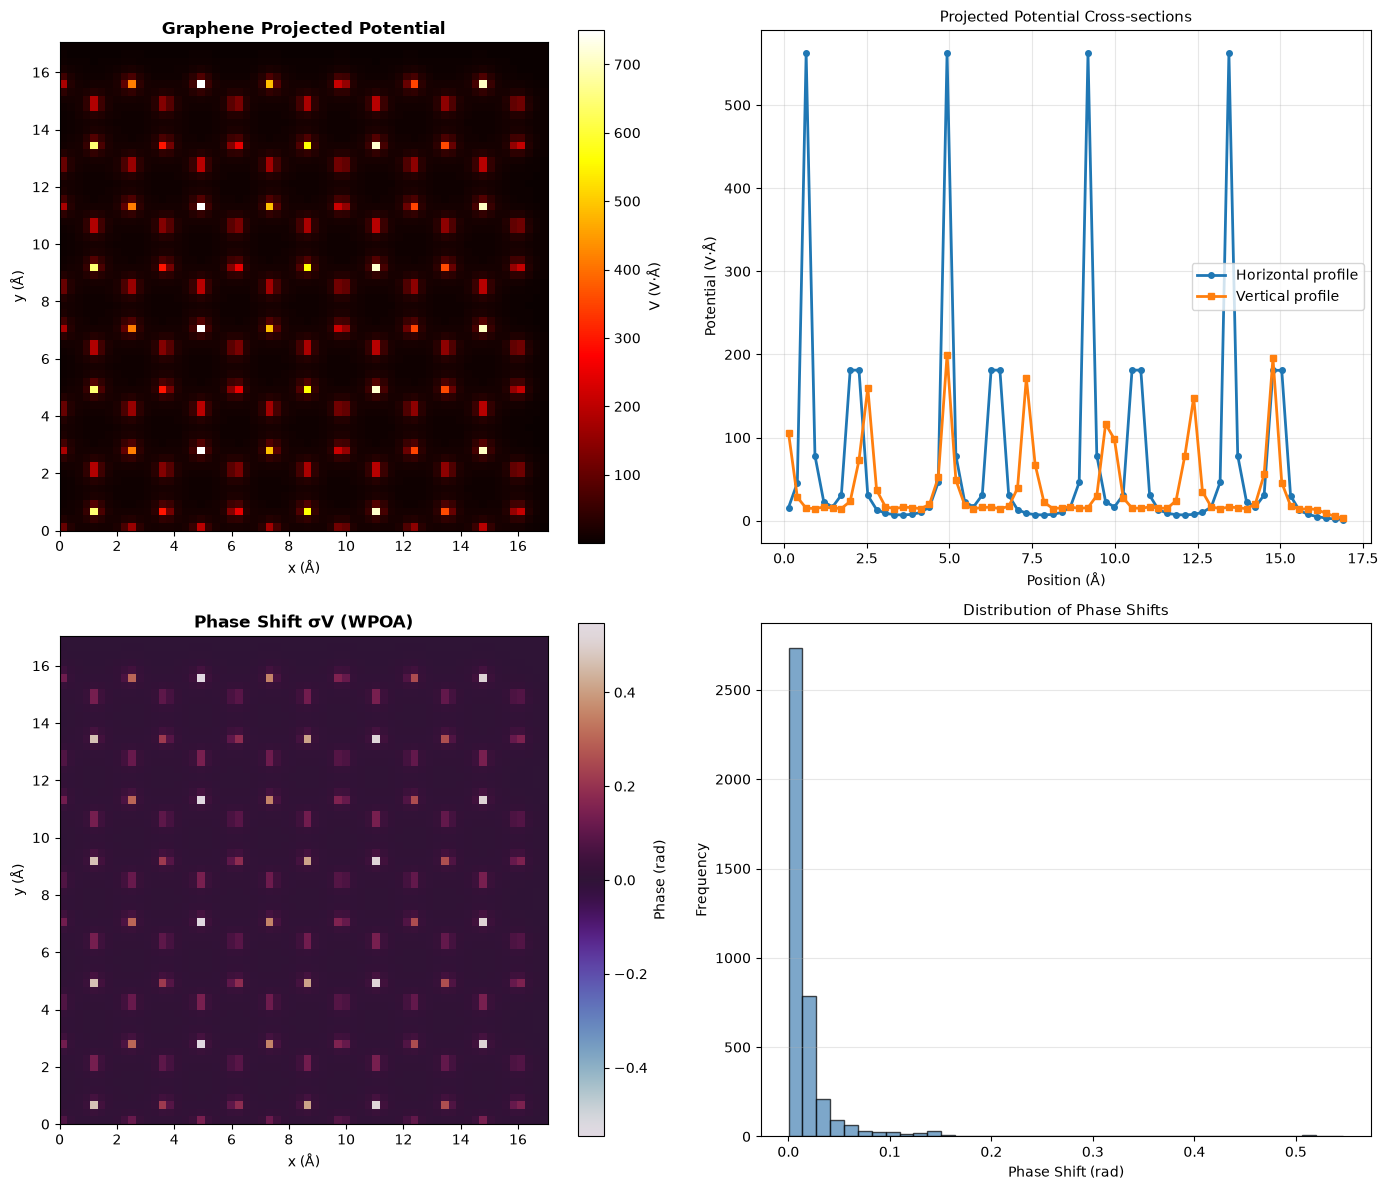


✓ Graphene monolayer from abTEM/ASE, Kirkland-parametrized potential
  Grid size: 64×64 pixels (0.2663 Å/pixel)
  Max potential: 750.289 V·Å
  Max phase shift: 0.5468 rad
  Atoms contributing: 112


In [6]:
# Visualize graphene structure and potential
ext = [0, grid_size_large * pixel_size, 0, grid_size_large * pixel_size]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Projected potential (real Kirkland units: V*A)
im1 = axes[0, 0].imshow(V_proj.T, cmap='hot', origin='lower', extent=ext)
axes[0, 0].set_title('Graphene Projected Potential', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('x (Å)')
axes[0, 0].set_ylabel('y (Å)')
cbar1 = plt.colorbar(im1, ax=axes[0, 0], label='V (V·Å)')

# Profile through center
center = V_proj.shape[0] // 2
coords_ax = (np.arange(grid_size_large) + 0.5) * pixel_size
axes[0, 1].plot(coords_ax, V_proj[center, :], 'o-', linewidth=2, label='Horizontal profile', markersize=4)
axes[0, 1].plot(coords_ax, V_proj[:, center], 's-', linewidth=2, label='Vertical profile', markersize=4)
axes[0, 1].set_title('Projected Potential Cross-sections', fontsize=11)
axes[0, 1].set_xlabel('Position (Å)')
axes[0, 1].set_ylabel('Potential (V·Å)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# WPOA: phase shift = sigma * V(x,y), where sigma is the real relativistic
# interaction constant (rad / (V*A)) at `voltage` -- not an arbitrary number.
wavelength_ctem = relativistic_wavelength(voltage)
sigma_interaction = interaction_constant(voltage, wavelength_ctem)
phase_shift_large = sigma_interaction * V_proj
print(f"Relativistic wavelength at {voltage/1e3:.0f} keV: {wavelength_ctem:.5f} Å")
print(f"Interaction constant sigma: {sigma_interaction:.4e} rad/(V·Å)")

phase_vmax = np.abs(phase_shift_large).max()
im2 = axes[1, 0].imshow(phase_shift_large.T, cmap='twilight', origin='lower', extent=ext,
                         vmin=-phase_vmax, vmax=phase_vmax)
axes[1, 0].set_title('Phase Shift σV (WPOA)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('x (Å)')
axes[1, 0].set_ylabel('y (Å)')
cbar2 = plt.colorbar(im2, ax=axes[1, 0], label='Phase (rad)')

# Phase shift statistics
axes[1, 1].hist(phase_shift_large.flatten(), bins=40, edgecolor='black', alpha=0.7, color='steelblue')
axes[1, 1].set_title('Distribution of Phase Shifts', fontsize=11)
axes[1, 1].set_xlabel('Phase Shift (rad)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n✓ Graphene monolayer from abTEM/ASE, Kirkland-parametrized potential")
print(f"  Grid size: {grid_size_large}×{grid_size_large} pixels ({pixel_size:.4f} Å/pixel)")
print(f"  Max potential: {V_proj.max():.3f} V·Å")
print(f"  Max phase shift: {phase_shift_large.max():.4f} rad")
print(f"  Atoms contributing: {len(in_view)}")


## 5. Contrast Transfer Function (CTF)

The CTF models aberrations and defocus in the microscope.

Microscope Parameters:
  Voltage: 200 keV
  Wavelength: 2.51 pm  (0.02508 Å)
  Cs: 1.30 mm
  Defocus: -650 Å
  Pixel size: 0.2663 Å (from the 64×64 graphene grid above)


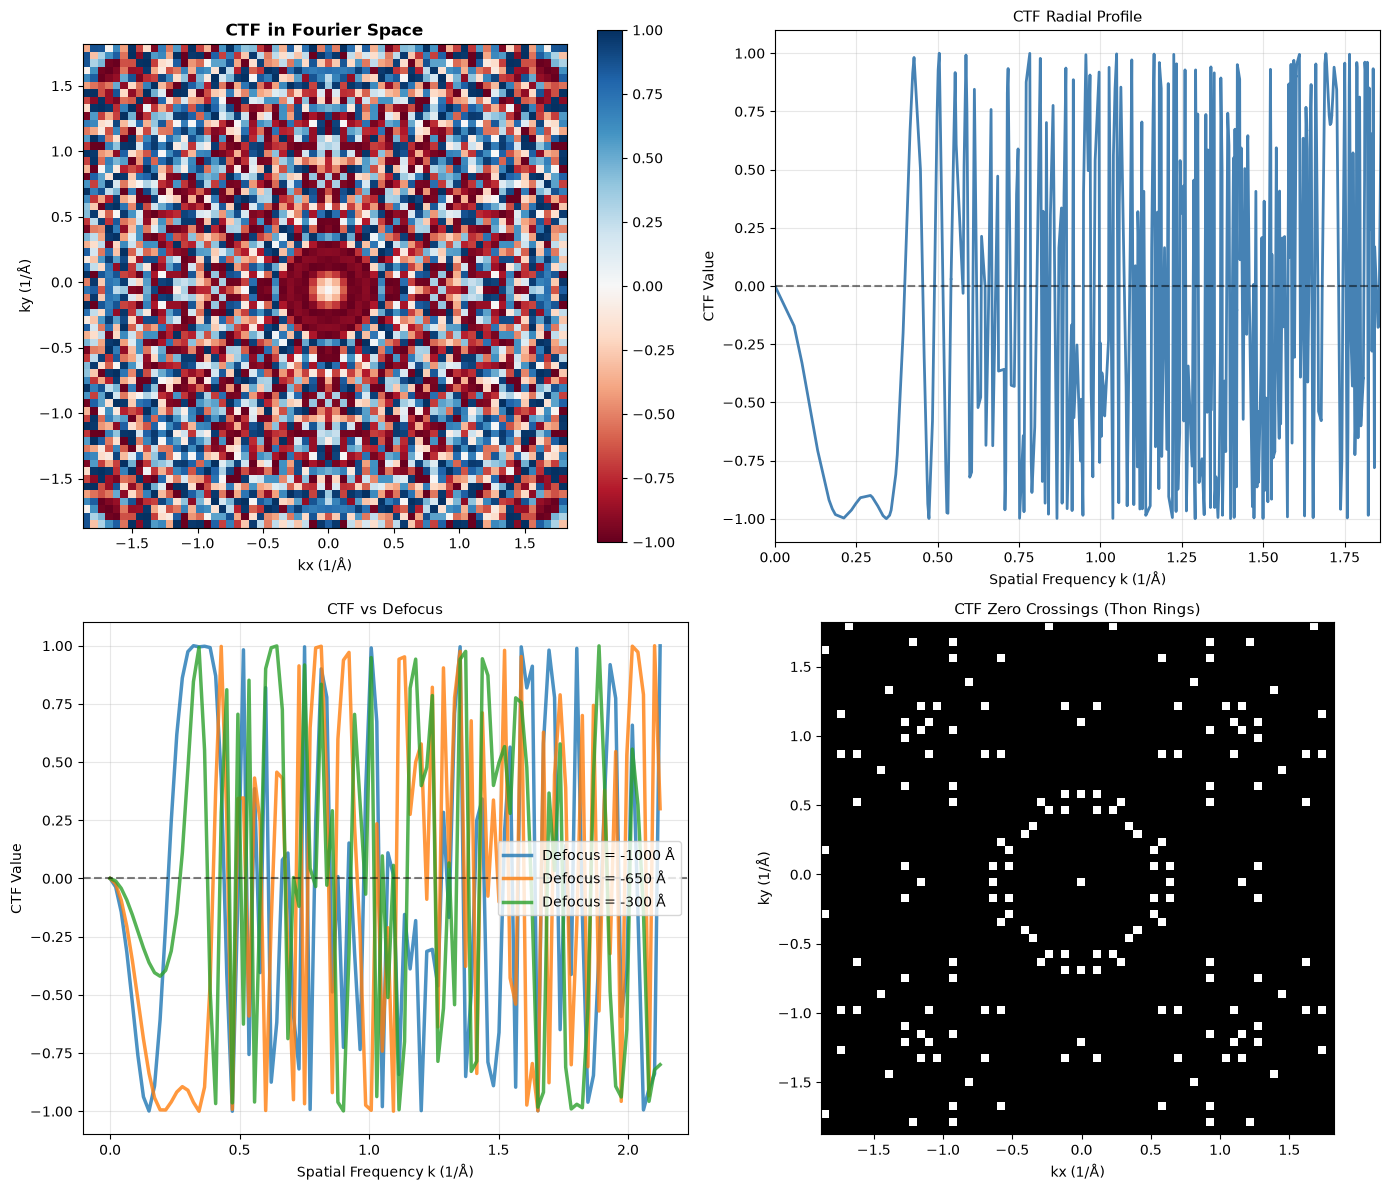


✓ CTF calculated for 64×64 grid
  CTF range: -1.000 to 1.000
  Low-frequency contrast (k<0.1): positive (weak)
  Mid-frequency contrast: negative (strong)
  High-frequency contrast: oscillates (weak)


In [7]:
# Microscope parameters - realistic values for 200 keV CTEM
# `voltage` and `pixel_size` are defined in the graphene-potential cell above,
# so the CTF's spatial-frequency grid matches the real sampling of V_proj.
wavelength = relativistic_wavelength(voltage)  # relativistic electron wavelength (A)
Cs = 1.3          # Spherical aberration coefficient (mm)
defocus = -650.0  # Defocus C1 (A) - negative = underfocus (stronger phase contrast)

print(f"Microscope Parameters:")
print(f"  Voltage: {voltage/1e3:.0f} keV")
print(f"  Wavelength: {wavelength*100:.2f} pm  ({wavelength:.5f} Å)")
print(f"  Cs: {Cs:.2f} mm")
print(f"  Defocus: {defocus:.0f} Å")
print(f"  Pixel size: {pixel_size:.4f} Å (from the {grid_size_large}×{grid_size_large} graphene grid above)")

# Spatial-frequency grid for the SAME grid_size_large x grid_size_large image
# at the real, isotropic pixel_size derived above -- not an assumed value.
freq_large = np.fft.fftfreq(grid_size_large, d=pixel_size)
kx_large, ky_large = np.meshgrid(freq_large, freq_large, indexing="ij")
k_sq_large = kx_large**2 + ky_large**2

# Aberration function chi(k) = pi*lambda*Df*k^2 + 0.5*pi*Cs*lambda^3*k^4
# (Kirkland convention: wavelength, defocus, pixel size and k all in
# Angstrom; Cs converted from mm to Angstrom by *1e7 -- exactly what
# QuScope's own LensCTFCircuit.calculate_chi does internally, so no other
# unit-conversion factors are needed).
Cs_A = Cs * 1e7
chi_large = (np.pi * wavelength * defocus * k_sq_large
             + 0.5 * np.pi * Cs_A * (wavelength**3) * (k_sq_large**2))
ctf_large = np.sin(chi_large)

# Visualize CTF for 64x64 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# CTF in 2D
im1 = axes[0, 0].imshow(np.fft.fftshift(ctf_large), cmap='RdBu', vmin=-1, vmax=1,
                         extent=[freq_large.min(), freq_large.max(), freq_large.min(), freq_large.max()])
axes[0, 0].set_title('CTF in Fourier Space', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('kx (1/Å)')
axes[0, 0].set_ylabel('ky (1/Å)')
cbar1 = plt.colorbar(im1, ax=axes[0, 0])

# CTF radial profile
k_radial = np.sqrt(k_sq_large).flatten()
ctf_flat = ctf_large.flatten()
sort_idx = np.argsort(k_radial)

axes[0, 1].plot(k_radial[sort_idx], ctf_flat[sort_idx], '-', linewidth=2, color='steelblue')
axes[0, 1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[0, 1].set_title('CTF Radial Profile', fontsize=11)
axes[0, 1].set_xlabel('Spatial Frequency k (1/Å)')
axes[0, 1].set_ylabel('CTF Value')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim(0, np.max(k_radial[sort_idx]) * 0.7)

# Defocus effect at different frequencies (values in Angstrom, matching `defocus` above)
frequencies = np.linspace(0, np.max(k_radial[sort_idx]) * 0.8, 100)
for defocus_test in [-1000.0, -650.0, -300.0]:
    chi_test = (np.pi * wavelength * defocus_test * frequencies**2
                + 0.5 * np.pi * Cs_A * (wavelength**3) * frequencies**4)
    ctf_test = np.sin(chi_test)
    axes[1, 0].plot(frequencies, ctf_test, linewidth=2.5,
                     label=f'Defocus = {defocus_test:.0f} Å', alpha=0.8)

axes[1, 0].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[1, 0].set_title('CTF vs Defocus', fontsize=11)
axes[1, 0].set_xlabel('Spatial Frequency k (1/Å)')
axes[1, 0].set_ylabel('CTF Value')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# CTF zero crossings (Thon rings indicator)
zero_crossings = np.abs(ctf_large) < 0.1
im2 = axes[1, 1].imshow(np.fft.fftshift(zero_crossings), cmap='gray',
                         extent=[freq_large.min(), freq_large.max(), freq_large.min(), freq_large.max()])
axes[1, 1].set_title('CTF Zero Crossings (Thon Rings)', fontsize=11)
axes[1, 1].set_xlabel('kx (1/Å)')
axes[1, 1].set_ylabel('ky (1/Å)')

plt.tight_layout()
plt.show()

print(f"\n✓ CTF calculated for {grid_size_large}×{grid_size_large} grid")
print(f"  CTF range: {ctf_large.min():.3f} to {ctf_large.max():.3f}")
print(f"  Low-frequency contrast (k<0.1): positive (weak)")
print(f"  Mid-frequency contrast: negative (strong)")
print(f"  High-frequency contrast: oscillates (weak)")


## 6. Complete Quantum CTEM Simulation

Now let's put it all together: encode → propagate → apply CTF → image formation.

Step 1: Incident plane wave on 12 qubits (64×64 grid)
Step 2: Applying WPOA phase grating exp(iσV) for graphene (σ=7.2884e-04 rad/(V·Å))
Step 3: Quantum Fourier Transform to momentum space
Step 4: Applying Contrast Transfer Function exp(iχ(k)) in momentum space
Step 5: Inverse QFT back to real space -> final CTEM image

Full circuit: 12 qubits, depth 5, 18 gates
Manual circuit vs. QuantumCTEMCircuit.simulate(): max|difference| = 0.00e+00
Quantum-classical fidelity (QuantumClassicalValidator): 1.000000


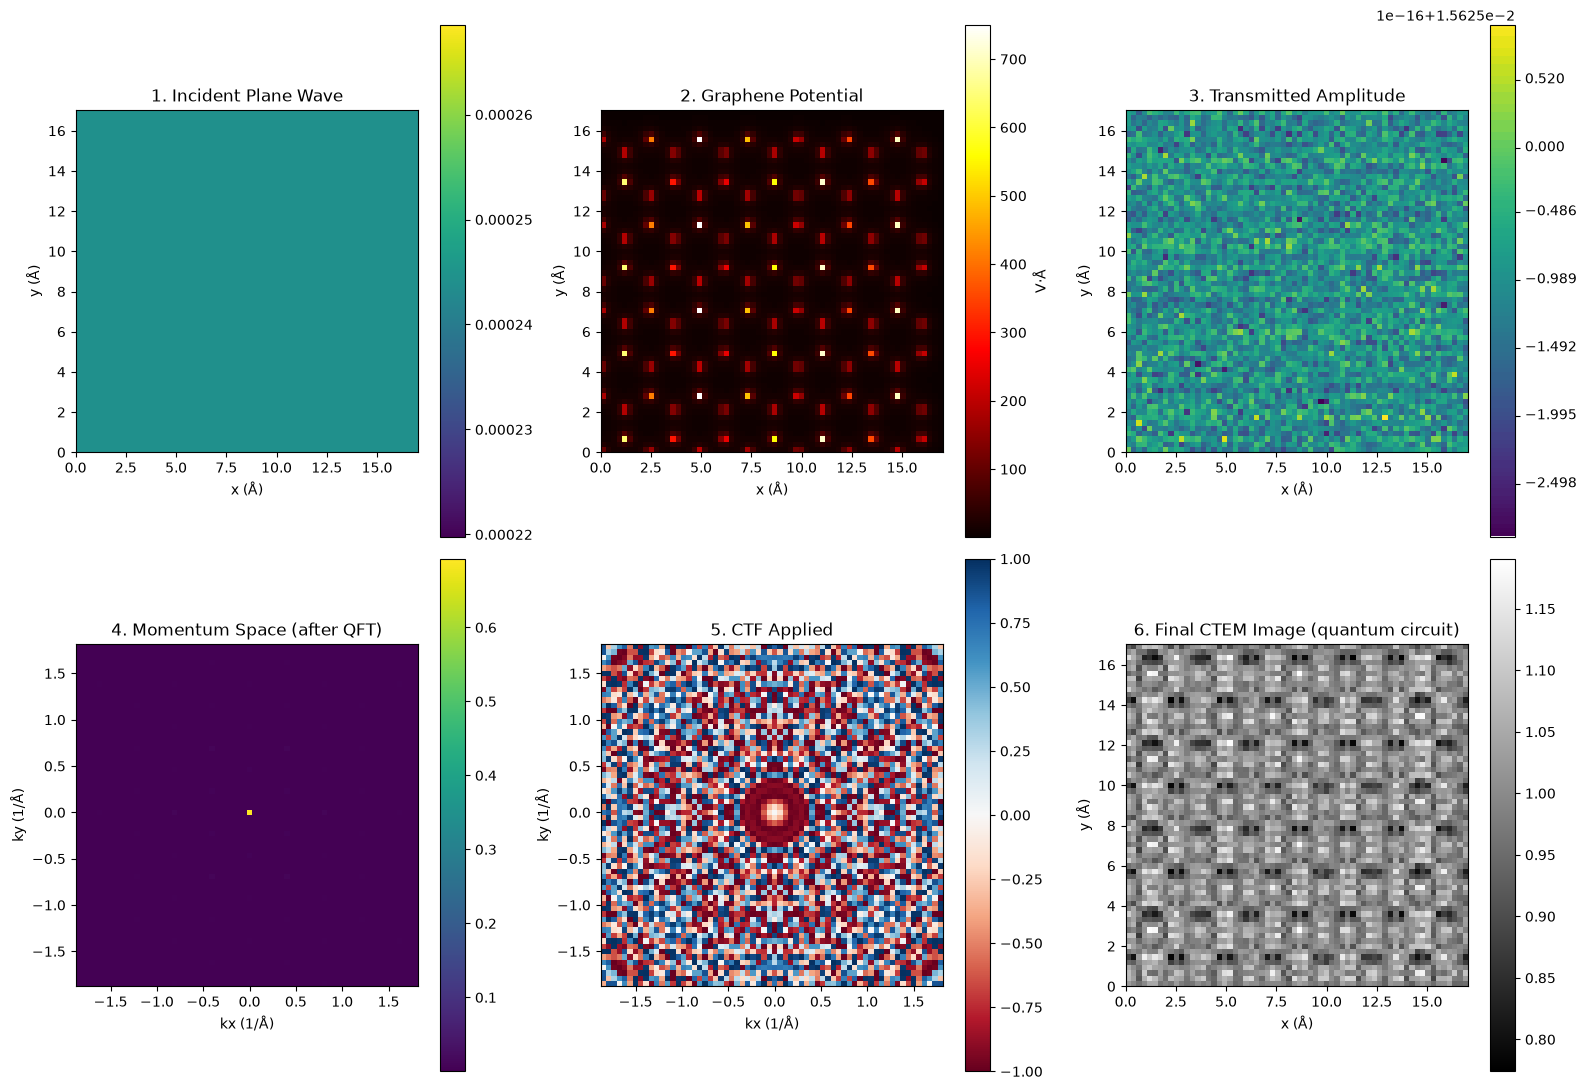

  Incident wave intensity: 2.441e-04 (uniform, plane wave)
  Transmitted amplitude range: 0.016 to 0.016
  Final image contrast: 0.7740 to 1.1906


In [8]:
# Build the SAME 5-stage circuit QuantumCTEMCircuit uses internally --
#   |psi0> -> H^n (plane wave) -> phase grating -> QFT -> CTF -> IQFT -> |psi_image>
# (see quscope.quantum_ctem.QuantumCTEMCircuit.build_full_circuit) -- extracting
# the statevector after every stage, so each step of "encode -> propagate ->
# apply CTF -> image formation" is a real quantum-circuit evolution executed
# with Qiskit's Statevector, not a classical FFT stand-in.
n_qubits_per_dim = int(np.log2(grid_size_large))   # 6
n_qubits_ctem = 2 * n_qubits_per_dim               # 12

print(f"Step 1: Incident plane wave on {n_qubits_ctem} qubits "
      f"({grid_size_large}×{grid_size_large} grid)")
h_circuit = QuantumCircuit(n_qubits_ctem)
h_circuit.h(range(n_qubits_ctem))
sv = Statevector.from_instruction(h_circuit)
incident_large = np.abs(sv.data.reshape(grid_size_large, grid_size_large)) ** 2

print(f"Step 2: Applying WPOA phase grating exp(iσV) for graphene "
      f"(σ={sigma_interaction:.4e} rad/(V·Å))")
sv = sv.evolve(PhaseGratingCircuit(n_qubits_ctem).build_circuit(V_proj, sigma_interaction))
transmitted_large = sv.data.reshape(grid_size_large, grid_size_large)

print("Step 3: Quantum Fourier Transform to momentum space")
qft = QFTGate(n_qubits_per_dim)
qft_circuit = QuantumCircuit(n_qubits_ctem)
qft_circuit.append(qft, range(n_qubits_per_dim))
qft_circuit.append(qft, range(n_qubits_per_dim, n_qubits_ctem))
sv = sv.evolve(qft_circuit)
exit_wave_momentum = sv.data.reshape(grid_size_large, grid_size_large)

print("Step 4: Applying Contrast Transfer Function exp(iχ(k)) in momentum space")
lens_ctf = LensCTFCircuit(n_qubits_ctem, n_qubits_per_dim, n_qubits_per_dim)
chi_large_ctem = lens_ctf.calculate_chi(wavelength, pixel_size, defocus, cs=Cs)
sv = sv.evolve(lens_ctf.build_circuit(chi_large_ctem))
ctf_large_ctem = np.sin(chi_large_ctem)

print("Step 5: Inverse QFT back to real space -> final CTEM image")
iqft_circuit = QuantumCircuit(n_qubits_ctem)
iqft_circuit.append(qft.inverse(), range(n_qubits_per_dim))
iqft_circuit.append(qft.inverse(), range(n_qubits_per_dim, n_qubits_ctem))
sv = sv.evolve(iqft_circuit)
final_image_large = np.abs(sv.data.reshape(grid_size_large, grid_size_large)) ** 2
final_image_large /= final_image_large.mean()

full_circuit = h_circuit.compose(
    PhaseGratingCircuit(n_qubits_ctem).build_circuit(V_proj, sigma_interaction)
).compose(qft_circuit).compose(
    lens_ctf.build_circuit(chi_large_ctem)
).compose(iqft_circuit)
print(f"\nFull circuit: {full_circuit.num_qubits} qubits, "
      f"depth {full_circuit.depth()}, {full_circuit.size()} gates")

# Cross-check the manual stage-by-stage circuit above against QuScope's public
# one-call API and its FFT-based classical twin.
ctem_params = QuantumCTEMParameters(
    acceleration_voltage=voltage, grid_size=grid_size_large, pixel_size=pixel_size,
    defocus=defocus, cs=Cs,
)
result_api = QuantumCTEMCircuit(ctem_params).simulate(V_proj)
fidelity = QuantumClassicalValidator(ctem_params).compare(V_proj).get("fidelity", float("nan"))
print(f"Manual circuit vs. QuantumCTEMCircuit.simulate(): "
      f"max|difference| = {np.abs(final_image_large - result_api['intensity']).max():.2e}")
print(f"Quantum-classical fidelity (QuantumClassicalValidator): {fidelity:.6f}")

# Visualize complete workflow at full resolution
fig, axes = plt.subplots(2, 3, figsize=(16, 11))
ext = [0, grid_size_large * pixel_size, 0, grid_size_large * pixel_size]
kext = [freq_large.min(), freq_large.max(), freq_large.min(), freq_large.max()]

im1 = axes[0, 0].imshow(incident_large.T, cmap='viridis', origin='lower', extent=ext)
axes[0, 0].set_title('1. Incident Plane Wave')
axes[0, 0].set_xlabel('x (Å)'); axes[0, 0].set_ylabel('y (Å)')
plt.colorbar(im1, ax=axes[0, 0])

im2 = axes[0, 1].imshow(V_proj.T, cmap='hot', origin='lower', extent=ext)
axes[0, 1].set_title('2. Graphene Potential')
axes[0, 1].set_xlabel('x (Å)'); axes[0, 1].set_ylabel('y (Å)')
plt.colorbar(im2, ax=axes[0, 1], label='V·Å')

im3 = axes[0, 2].imshow(np.abs(transmitted_large).T, cmap='viridis', origin='lower', extent=ext)
axes[0, 2].set_title('3. Transmitted Amplitude')
axes[0, 2].set_xlabel('x (Å)'); axes[0, 2].set_ylabel('y (Å)')
plt.colorbar(im3, ax=axes[0, 2])

im4 = axes[1, 0].imshow(np.fft.fftshift(np.log(1 + np.abs(exit_wave_momentum))).T,
                         cmap='viridis', origin='lower', extent=kext)
axes[1, 0].set_title('4. Momentum Space (after QFT)')
axes[1, 0].set_xlabel('kx (1/Å)'); axes[1, 0].set_ylabel('ky (1/Å)')
plt.colorbar(im4, ax=axes[1, 0])

im5 = axes[1, 1].imshow(np.fft.fftshift(ctf_large_ctem).T, cmap='RdBu', vmin=-1, vmax=1,
                         origin='lower', extent=kext)
axes[1, 1].set_title('5. CTF Applied')
axes[1, 1].set_xlabel('kx (1/Å)'); axes[1, 1].set_ylabel('ky (1/Å)')
plt.colorbar(im5, ax=axes[1, 1])

im6 = axes[1, 2].imshow(final_image_large.T, cmap='gray', origin='lower', extent=ext)
axes[1, 2].set_title('6. Final CTEM Image (quantum circuit)')
axes[1, 2].set_xlabel('x (Å)'); axes[1, 2].set_ylabel('y (Å)')
plt.colorbar(im6, ax=axes[1, 2])

plt.tight_layout()
plt.show()

print(f"  Incident wave intensity: {incident_large.max():.3e} (uniform, plane wave)")
print(f"  Transmitted amplitude range: {np.abs(transmitted_large).min():.3f} to {np.abs(transmitted_large).max():.3f}")
print(f"  Final image contrast: {final_image_large.min():.4f} to {final_image_large.max():.4f}")
